# Регрессия: предсказание SI

SI (Selectivity Index) = CC50/IC50. Высокие значения SI означают хорошую избирательность — соединение активно против вируса, но не токсично для клеток. **Важно:** признаки IC50 и CC50 исключены во избежание утечки данных.

Применяется **log1p-преобразование** целевой переменной ввиду сильной правой асимметрии распределения.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor


In [8]:
df = pd.read_excel('/content/Данные_для_курсовои_Классическое_МО (1).xlsx',index_col=0)
TARGET = 'SI'
FEATURE_EXCLUDE = ['IC50, mM', 'CC50, mM', 'SI']
features = [c for c in df.columns if c not in FEATURE_EXCLUDE]

X = df[features]
y = np.log1p(df[TARGET])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Целевая переменная: {TARGET}')
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Среднее y_train: {y_train.mean():.3f}, std: {y_train.std():.3f}')

Целевая переменная: SI
Train: (800, 210), Test: (201, 210)
Среднее y_train: 2.050, std: 1.430


In [9]:
results = {}

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [10]:
X_train.isna().sum().sum()

np.int64(24)

In [16]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

Воспользуемся Ridge с Lasso как baseline. Они нужны для сравнения — чтобы понять, что ансамблевые методы (Random Forest, Gradient Boosting) работают лучше.

**Ridge**

In [17]:
ridge_pipe = Pipeline([('scaler', StandardScaler()), ('model', Ridge())])
param_grid = {'model__alpha': [0.01, 0.1, 1, 10, 100]}
gs_ridge = GridSearchCV(ridge_pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
gs_ridge.fit(X_train, y_train)
pred_ridge = gs_ridge.predict(X_test)

results['Ridge'] = {'R2': r2_score(y_test, pred_ridge), 'RMSE': rmse(y_test, pred_ridge)}
print(f'Best alpha: {gs_ridge.best_params_}')
print(f'R² = {results["Ridge"]["R2"]:.3f}, RMSE = {results["Ridge"]["RMSE"]:.3f}')

Best alpha: {'model__alpha': 100}
R² = 0.184, RMSE = 1.405


Ridge показал слабый результат. Высокая alpha говорит о сильной мультиколлинеарности признаков.

# **Lasso**

In [18]:
lasso_pipe = Pipeline([('scaler', StandardScaler()), ('model', Lasso(max_iter=5000))])
param_grid_lasso = {'model__alpha': [0.001, 0.01, 0.1, 1, 10]}
gs_lasso = GridSearchCV(lasso_pipe, param_grid_lasso, cv=5, scoring='r2', n_jobs=-1)
gs_lasso.fit(X_train, y_train)
pred_lasso = gs_lasso.predict(X_test)

results['Lasso'] = {'R2': r2_score(y_test, pred_lasso), 'RMSE': rmse(y_test, pred_lasso)}

coef = gs_lasso.best_estimator_['model'].coef_
print(f'Признаков с ненулевым коэффициентом: {(coef != 0).sum()} из {len(coef)}')
print(f'R² = {results["Lasso"]["R2"]:.3f}, RMSE = {results["Lasso"]["RMSE"]:.3f}')

Признаков с ненулевым коэффициентом: 16 из 210
R² = 0.108, RMSE = 1.469


Lasso справился хуже Ridge и отобрал только 16 признаков из 210 — большинство признаков линейно не связаны с SI.

**Random Forest**

In [19]:
param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [None, 15], 'min_samples_leaf': [1, 2]}
gs_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
gs_rf.fit(X_train, y_train)
pred_rf = gs_rf.predict(X_test)

results['Random Forest'] = {'R2': r2_score(y_test, pred_rf), 'RMSE': rmse(y_test, pred_rf)}
print(f'Best: {gs_rf.best_params_}')
print(f'R² = {results["Random Forest"]["R2"]:.3f}, RMSE = {results["Random Forest"]["RMSE"]:.3f}')

Best: {'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 200}
R² = 0.331, RMSE = 1.273


Random Forest значительно лучше линейных моделей - R² вырос с 0.184 до 0.331. Ограничение глубины до 15 помогло избежать переобучения.

**Gradient Busting**

In [20]:
param_grid_gb = {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 4]}
gs_gb = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid_gb, cv=5, scoring='r2', n_jobs=-1)
gs_gb.fit(X_train, y_train)
pred_gb = gs_gb.predict(X_test)

results['Gradient Boosting'] = {'R2': r2_score(y_test, pred_gb), 'RMSE': rmse(y_test, pred_gb)}
print(f'Best: {gs_gb.best_params_}')
print(f'R² = {results["Gradient Boosting"]["R2"]:.3f}, RMSE = {results["Gradient Boosting"]["RMSE"]:.3f}')

Best: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
R² = 0.283, RMSE = 1.317


Gradient Boosting хуже Random Forest для SI — R² = 0.283 против 0.331

## Cравнение результатов

                       R2    RMSE
Random Forest      0.3309  1.2725
Gradient Boosting  0.2831  1.3172
Ridge              0.1838  1.4054
Lasso              0.1081  1.4692


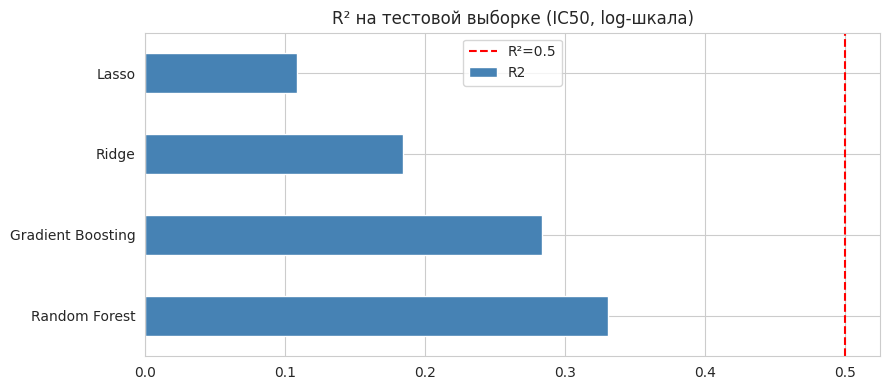

In [21]:
res_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print(res_df.round(4))

res_df['R2'].plot(kind='barh', figsize=(9, 4), color='steelblue')
plt.axvline(0.5, color='red', linestyle='--', label='R²=0.5')
plt.title('R² на тестовой выборке (IC50, log-шкала)')
plt.legend()
plt.tight_layout()
plt.show()

## Важность признаков

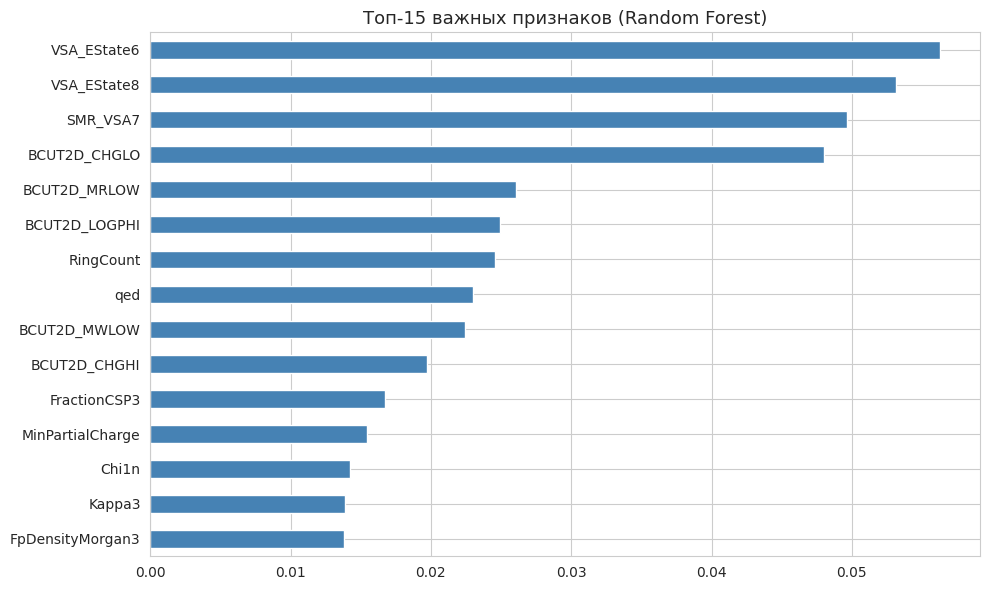

In [22]:
res_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
best_model_name = res_df.index[0]

if 'Random Forest' in best_model_name:
    best_model = gs_rf.best_estimator_
elif 'Gradient Boosting' in best_model_name:
    best_model = gs_gb.best_estimator_
else:
    best_model = None

if best_model is not None:
    importances = pd.Series(best_model.feature_importances_, index=features)
    top_feat = importances.sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(10, 6))
    top_feat[::-1].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Топ-15 важных признаков ({best_model_name})', fontsize=13)
    plt.tight_layout()
    plt.show()

## Анализ ошибок лучшей модели

In [ ]:
best_pred = pred_rf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, best_pred, s=15, alpha=0.4)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--')
axes[0].set_title('Random Forest: y_true vs y_pred')

axes[1].scatter(best_pred, y_test - best_pred, s=15, alpha=0.4)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_title('Residuals')

plt.tight_layout()
plt.show()

## Выводы

Лучшей моделью для предсказания SI оказался Random Forest (R² = 0.331). В целом все модели показали низкий R² - это ожидаемо, так как SI исключает IC50 и CC50 из признаков, а именно они математически определяют SI. Предсказывать SI только по молекулярным дескрипторам значительно сложнее. Линейные модели (Ridge R² = 0.184, Lasso R² = 0.108) ожидаемо слабее ансамблевых.
